In [15]:
import pandas as pd
import numpy as np

# Import winequality-red.csv with semicolon separator
wine_data = pd.read_csv('winequality-red.csv', sep=';')

# Display basic information about the dataset
print("Dataset shape:", wine_data.shape)
print("\nFirst few rows:")
print(wine_data.head())

print("\nDataset info:")
print(wine_data.info())

print("\nColumn names:")
print(wine_data.columns.tolist())

# Separate features and target
X = wine_data.drop('quality', axis=1)  # 'quality' is the target column
y = wine_data['quality']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target values: {sorted(y.unique())}")

print(y.values)

Dataset shape: (1599, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  

Training data: (1119, 11), Testing data: (480, 11)
Training accuracy = 0.5817694369973191
Training Confusion Matrix
[[  0   0   7   0   0   0]
 [  0   0  24  13   0   0]
 [  0   0 361 116   0   0]
 [  0   0 156 290   0   0]
 [  0   0   8 131   0   0]
 [  0   0   0  13   0   0]]
Training Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00        37
           5       0.65      0.76      0.70       477
           6       0.52      0.65      0.57       446
           7       0.00      0.00      0.00       139
           8       0.00      0.00      0.00        13

    accuracy                           0.58      1119
   macro avg       0.19      0.23      0.21      1119
weighted avg       0.48      0.58      0.53      1119



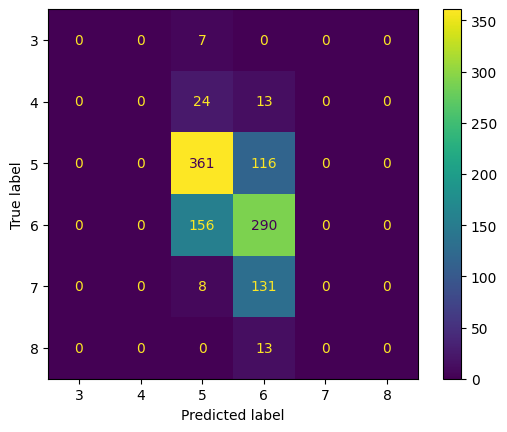

Test accuracy = 0.5875
Test Confusion Matrix
[[  0   0   2   1   0   0]
 [  0   0  13   3   0   0]
 [  0   0 150  54   0   0]
 [  0   0  60 132   0   0]
 [  0   0   3  57   0   0]
 [  0   0   0   5   0   0]]
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.66      0.74      0.69       204
           6       0.52      0.69      0.59       192
           7       0.00      0.00      0.00        60
           8       0.00      0.00      0.00         5

    accuracy                           0.59       480
   macro avg       0.20      0.24      0.21       480
weighted avg       0.49      0.59      0.53       480



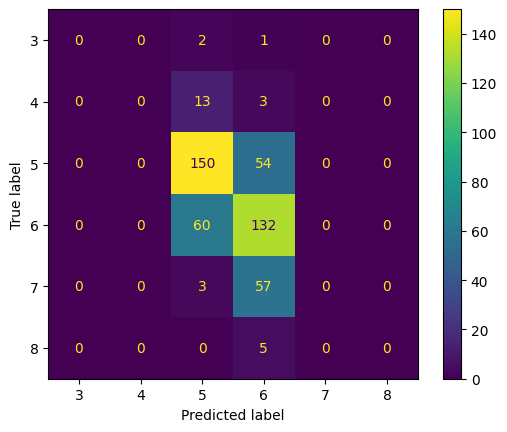

In [16]:
from sklearn.model_selection import train_test_split

# 75% training and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# OvO
svm_ovo = svm.SVC(decision_function_shape='ovo', kernel='linear', C=1.0, random_state=0)
svm_ovo.fit(X_train, y_train)
# Predictions
y_pred_train = svm_ovo.predict(X_train)
y_pred_test = svm_ovo.predict(X_test)

print(f"Training accuracy = {svm_ovo.score(X_train, y_train)}")
print('Training Confusion Matrix')
print(confusion_matrix(y_train, svm_ovo.predict(X_train)))
print('Training Classification Report')
print(classification_report(y_train, svm_ovo.predict(X_train)))

ConfusionMatrixDisplay.from_estimator(svm_ovo, X_train, y_train)
plt.show()

print(f"Test accuracy = {svm_ovo.score(X_test, y_test)}")
print('Test Confusion Matrix')
print(confusion_matrix(y_test, svm_ovo.predict(X_test)))
print('Test Classification Report')
print(classification_report(y_test, svm_ovo.predict(X_test)))

ConfusionMatrixDisplay.from_estimator(svm_ovo, X_test, y_test)
plt.show()

# from sklearn.inspection import DecisionBoundaryDisplay

# # Select only the first two features for visualization
# X_vis = X.iloc[:, :2]
# X_train_vis = X_train.iloc[:, :2]
# X_test_vis = X_test.iloc[:, :2]

# # Train a new SVM on only two features for visualization
# svm_ovo_vis = svm.SVC(decision_function_shape='ovo', kernel='linear', C=1.0, random_state=0)
# svm_ovo_vis.fit(X_train_vis, y_train)

# DecisionBoundaryDisplay.from_estimator(svm_ovo_vis, X_vis, alpha=0.8, eps=0.5)
# plt.scatter(X_train_vis.iloc[:, 0], X_train_vis.iloc[:, 1], marker='o', edgecolors="k", label="Train")
# plt.scatter(X_test_vis.iloc[:, 0], X_test_vis.iloc[:, 1], marker='x', edgecolors="k", label="Test")
# plt.xlabel(X_vis.columns[0])
# plt.ylabel(X_vis.columns[1])
# plt.legend()
# plt.show()

Training data: (1119, 11), Testing data: (480, 11)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END classify__activation=tanh, classify__alpha=5.808948960148735, classify__hidden_layer_sizes=9, classify__solver=sgd;, score=0.656 total time=   0.7s
[CV 2/5] END classify__activation=tanh, classify__alpha=5.808948960148735, classify__hidden_layer_sizes=9, classify__solver=sgd;, score=0.580 total time=   0.5s
[CV 3/5] END classify__activation=tanh, classify__alpha=5.808948960148735, classify__hidden_layer_sizes=9, classify__solver=sgd;, score=0.558 total time=   0.6s
[CV 4/5] END classify__activation=tanh, classify__alpha=5.808948960148735, classify__hidden_layer_sizes=9, classify__solver=sgd;, score=0.562 total time=   0.6s
[CV 5/5] END classify__activation=tanh, classify__alpha=5.808948960148735, classify__hidden_layer_sizes=9, classify__solver=sgd;, score=0.601 total time=   0.6s
[CV 1/5] END classify__activation=tanh, classify__alpha=1.0285923226784484, classi

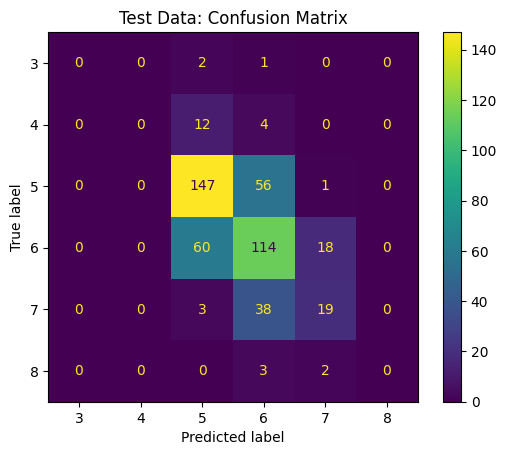

In [17]:
import numpy as np
from time import time
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from scipy.stats import randint, loguniform
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Split into 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

# # Reduce data to 2 principal components
# pca = PCA(n_components=2)
# X_train_pca = pca.fit_transform(X_train,y_train)
# X_test_pca = pca.transform(X_test)
# X_pca = np.vstack((X_train_pca,X_test_pca))

# # Visualize the reduced training and test data
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
# for color, i, target_name in zip(colors, [0, 1, 2], target_names):
#     plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], 
#                 color=color, alpha=0.8, lw=2, label=f"{target_name} train")
#     plt.scatter(X_test_pca[y_test == i, 0], X_test_pca[y_test == i, 1], 
#                 color=color, alpha=0.8, lw=2, label=f"{target_name} test", marker='x')

# plt.axis([-4, 5, -2, 2])
# plt.legend(loc="best", shadow=False)
# plt.title("PCA of IRIS dataset")
# plt.grid()
# plt.show()


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", MLPClassifier(max_iter=5000))]
)

model_params = {'classify__alpha': loguniform(1e-4, 10),
                'classify__solver': ['sgd','adam'],
                'classify__hidden_layer_sizes': randint(4,16),
                'classify__activation': ['identity','logistic','tanh','relu']}

# cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

# n_iter = 50
# random_search = RandomizedSearchCV(pipeline, cv=cv,
#                                    param_distributions=model_params, 
#                                    n_iter=n_iter, verbose=3)

n_iter = 50
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

# Print best parameters after tuning
print(random_search.best_params_)
  
# Print how our model looks after hyper-parameter tuning
print(random_search.best_estimator_)

random_predictions = random_search.predict(X_test)
  
# print classification report
print(classification_report(y_test, random_predictions))

cfm = confusion_matrix(y_test, random_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm, display_labels=np.sort(y_test.unique()))
cm_display.plot()
plt.title('Test Data: Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00        37
           5       1.00      1.00      1.00       477
           6       1.00      1.00      1.00       446
           7       1.00      1.00      1.00       139
           8       1.00      1.00      1.00        13

    accuracy                           1.00      1119
   macro avg       1.00      1.00      1.00      1119
weighted avg       1.00      1.00      1.00      1119

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.72      0.80      0.76       204
           6       0.66      0.65      0.65       192
           7       0.59      0.57      0.58        60
           8       0.50      0.20      0.29         5

    accuracy                           0.67       480
   macro avg       0.41

Text(0.5, 1.0, 'Testing Data: Confusion Matrix')

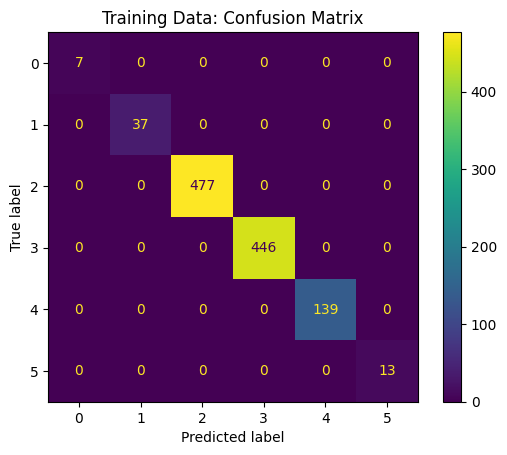

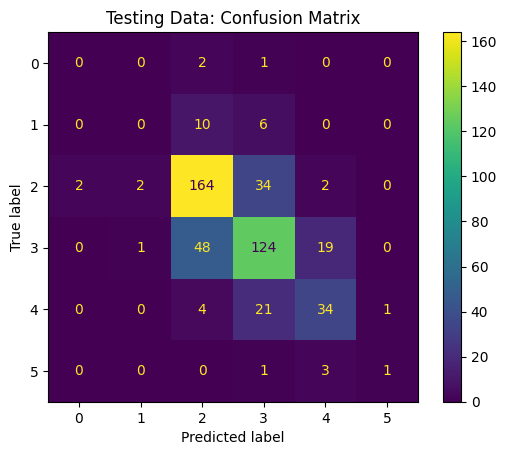

In [18]:
import seaborn as sns
import xgboost as xgb
import pandas as pd
import numpy as np
import math
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
# print classification report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
warnings.filterwarnings("ignore")

# Encode target labels to 0-based indices for XGBoost
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Number of classes
num_classes = len(label_encoder.classes_)

# Create classification matrices
dtrain_clf = xgb.DMatrix(X_train, y_train_enc, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test_enc, enable_categorical=True)

params = {"objective": "multi:softprob", "num_class": num_classes}
n = 1000

model = xgb.train(
   params=params,
   dtrain=dtrain_clf,
   num_boost_round=n
)

# XGBoost with cross-validation is used
results = xgb.cv(
   params, dtrain_clf,
   num_boost_round=n,
   nfold=5,
   metrics=["mlogloss", "auc", "merror"])

y_pred_train = model.predict(dtrain_clf)
y_pred_test = model.predict(dtest_clf)

# Decode predictions back to original labels
y_pred_train_labels = label_encoder.inverse_transform(y_pred_train.argmax(axis=1))
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test.argmax(axis=1))

print(classification_report(y_train, y_pred_train_labels))
print(classification_report(y_test, y_pred_test_labels))

cfm = confusion_matrix(y_train, y_pred_train_labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm)
cm_display.plot()
plt.title('Training Data: Confusion Matrix')

cfm = confusion_matrix(y_test, y_pred_test_labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm)
cm_display.plot()
plt.title('Testing Data: Confusion Matrix')

Best hyperparameters: {'max_depth': 16, 'n_estimators': 124}
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00        37
           5       1.00      1.00      1.00       477
           6       1.00      1.00      1.00       446
           7       1.00      1.00      1.00       139
           8       1.00      1.00      1.00        13

    accuracy                           1.00      1119
   macro avg       1.00      1.00      1.00      1119
weighted avg       1.00      1.00      1.00      1119

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.73      0.78      0.75       204
           6       0.64      0.69      0.66       192
           7       0.62      0.53      0.57        60
           8       1.00      0.20      0.33         5

    accuracy    

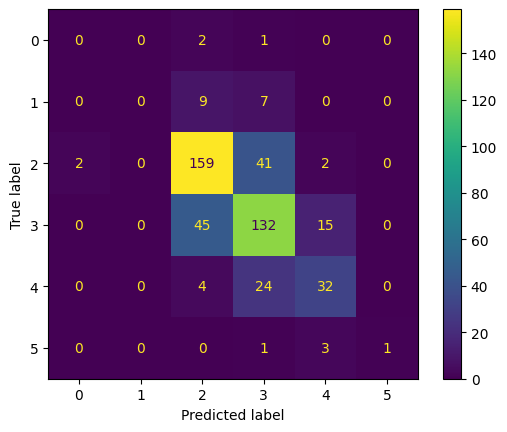

In [19]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
print(classification_report(y_train, best_rf.predict(X_train)))
print(classification_report(y_test, y_pred))

